# Tutorial to Least Squares and Recursive Least Squares applied to Runner Timing Simulation

In [ ]:
from IPython.display import display, HTML

display(HTML("""
<style>
.jp-RenderedHTMLCommon {
    max-width: 60vw;
    line-height: 1.5;
}
</style>
"""))

## Runner Performance Modeling with Least Squares

In this tutorial, we will use a simulation to explore how Least Squares (LS) and Recursive Least Squares (RLS) can be applied to estimate a runner's performance.

Imagine a scenario where a runner trains daily, and multiple coaches record their sprint times using stopwatches. In addition to the runner's inherent ability (baseline performance), their timing is also affected by environmental factors, primarily wind. Each coach might also have a slight bias in their stopwatch readings.

Our primary goal is not just academic estimation, but to achieve an **accurate and reliable prediction of the runner's performance for competition**. Since we'll rely on stopwatch timings and coach observations during competition (without a 'true' sophisticated timer), precisely estimating the runner's **baseline performance** (their time under normal, windless conditions), the distinct **impact of headwind and tailwind** on their speed, and critically, **each coach's individual measurement bias**, becomes essential. This model will allow us to correct for these factors and make robust performance predictions.

We define the observed time ($T$) for a run as:

$$T = T_{baseline} + W_{headwind} \cdot V_{headwind} + W_{tailwind} \cdot V_{tailwind} + B_{coach} + \epsilon$$

Where:
*   $T_{baseline}$ is the runner's true baseline time (what we want to estimate).
*   $W_{headwind}$ is a coefficient representing the headwind's effect on time (e.g., seconds per m/s headwind speed).
*   $V_{headwind}$ is the measured headwind speed (positive when wind is against the runner).
*   $W_{tailwind}$ is a coefficient representing the tailwind's effect on time (e.g., seconds per m/s tailwind speed).
*   $V_{tailwind}$ is the measured tailwind speed (positive when wind is with the runner).
*   $B_{coach}$ is the bias of the specific coach measuring the time.
*   $\epsilon$ is random measurement error (noise).

This problem can be formulated as a linear system suitable for Least Squares estimation.

### Formulating the Runner Timing Problem as a Linear System (Ax=B)

To apply Least Squares, we transform our runner timing model into the standard linear system form:

$$\mathbf{A} \mathbf{x} = \mathbf{b}$$

Where:
*   $\mathbf{x}$ is the vector of unknown parameters we want to estimate.
*   $\mathbf{A}$ is the design matrix, containing the known coefficients (wind speed, coach indicators).
*   $\mathbf{b}$ is the vector of observed measurements (runner's recorded times).

Let's assume our unknown parameter vector $\mathbf{x}$ consists of:

$$\mathbf{x} = \begin{bmatrix} T_{baseline} \\ W_{headwind} \\ W_{tailwind} \\ B_{coach1} \\ B_{coach2} \\ \vdots \end{bmatrix}$$

For each measurement (a run timed by a specific coach under certain wind conditions), we can form a row in the $\mathbf{A}$ matrix and an entry in the $\mathbf{b}$ vector.

For example, if Coach 1 times a run with wind speed $V_{wind}$ (where $V_{wind}$ is positive for tailwind and negative for headwind):

*   If $V_{wind} > 0$ (tailwind): $V_{headwind} = 0$, $V_{tailwind} = V_{wind}$. The row in $\mathbf{A}$ would be `[1, 0, V_wind, 1, 0, ...]`, and the entry in $\mathbf{b}$ would be the recorded time.
*   If $V_{wind} < 0$ (headwind): $V_{headwind} = |V_{wind}|$, $V_{tailwind} = 0$. The row in $\mathbf{A}$ would be `[1, |V_wind|, 0, 1, 0, ...]`, and the entry in $\mathbf{b}$ would be the recorded time.

The `1` for $T_{baseline}$ means it always contributes to the total time. The `1` for $B_{coach1}$ means that this specific coach's bias is active for this measurement. If Coach 2 timed it, that row would be `[1, ..., 0, 1, ...]`, and so on.

Each row in $\mathbf{A}$ represents a single observation (a timed run), and each column corresponds to a parameter in $\mathbf{x}$.

This setup allows us to leverage the power of linear algebra to find the best-fit estimates for our runner's performance and environmental factors.

#### Python imports
Prior to beginning this jupyter-notebook tutorial, we can include some python imports.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Simulation Parameters ---
np.random.seed(42)

# True underlying parameters for the runner's performance model
true_baseline_time = 10.0 # seconds for a specific distance under ideal conditions
true_headwind_effect_coeff = 0.1 # seconds per m/s (positive means headwind slows down)
true_tailwind_effect_coeff = -0.1 # seconds per m/s (negative means tailwind speeds up)
true_coach_biases = {
    'Coach A': 0.1,  # Coach A tends to be 0.1 seconds slow
    'Coach B': -0.05, # Coach B tends to be 0.05 seconds fast
    'Coach C': 0.0   # Coach C is unbiased
}

num_runs_per_day = 5
num_coaches = len(true_coach_biases)
coach_names = list(true_coach_biases.keys())
num_days_to_simulate = 50 # Simulate data for 50 days

# --- Generate daily simulated data ---
def generate_daily_data(day_number, true_baseline, true_headwind_effect_coeff, true_tailwind_effect_coeff, true_coach_biases, num_runs, coach_names):
    observed_times = []
    wind_speeds_raw = []
    headwind_speeds = []
    tailwind_speeds = []
    coach_indices = []

    for _ in range(num_runs):
        # Simulate wind speed (e.g., from -5 m/s (headwind) to +5 m/s (tailwind))
        # Negative wind speed: headwind. Positive wind speed: tailwind.
        wind_raw = np.random.uniform(-5, 5)

        current_headwind = 0.0
        current_tailwind = 0.0
        if wind_raw < 0: # Headwind
            current_headwind = abs(wind_raw)
        else: # Tailwind
            current_tailwind = wind_raw

        # Randomly assign a coach for this run
        coach_name = np.random.choice(coach_names)
        coach_bias = true_coach_biases[coach_name]

        # True time = baseline + headwind_effect * headwind_speed + tailwind_effect * tailwind_speed + coach_bias + noise
        noise = np.random.normal(0, 0.05) # Small measurement noise
        observed_time = (true_baseline +
                         true_headwind_effect_coeff * current_headwind +
                         true_tailwind_effect_coeff * current_tailwind +
                         coach_bias +
                         noise)

        observed_times.append(observed_time)
        wind_speeds_raw.append(wind_raw)
        headwind_speeds.append(current_headwind)
        tailwind_speeds.append(current_tailwind)
        coach_indices.append(coach_name)

    df_day = pd.DataFrame({
        'day': day_number,
        'headwind_speed': headwind_speeds,
        'tailwind_speed': tailwind_speeds,
        'coach': coach_indices,
        'observed_time': observed_times
    })
    return df_day

# Generate data for multiple days
all_daily_data = []
for day in range(1, num_days_to_simulate + 1):
    all_daily_data.append(generate_daily_data(day, true_baseline_time, true_headwind_effect_coeff, true_tailwind_effect_coeff, true_coach_biases, num_runs_per_day, coach_names))

df_all_data = pd.concat(all_daily_data, ignore_index=True)

print(f"Simulated Data for {num_days_to_simulate} Days (first 5 rows):")
display(df_all_data.head())

# --- Construct A and b for a given DataFrame ---
def construct_A_b(df, coach_names):
    num_params = 1 + 2 + len(coach_names) # Baseline, Headwind Effect, Tailwind Effect, Coach Biases
    A = np.zeros((len(df), num_params))
    b = df['observed_time'].values.reshape(-1, 1)

    # Map coach names to column indices
    # Baseline is index 0, Headwind Effect is index 1, Tailwind Effect is index 2, Coaches start from index 3
    coach_to_idx = {name: i + 3 for i, name in enumerate(coach_names)}

    for local_idx, (original_idx, row) in enumerate(df.iterrows()): # Use local_idx for A
        A[local_idx, 0] = 1 # Coefficient for T_baseline
        A[local_idx, 1] = row['headwind_speed'] # Coefficient for W_headwind
        A[local_idx, 2] = row['tailwind_speed'] # Coefficient for W_tailwind
        A[local_idx, coach_to_idx[row['coach']]] = 1 # Coefficient for B_coach

    # Define the parameter vector 'x' for context
    param_names = ['T_baseline', 'W_headwind', 'W_tailwind'] + [f'B_{c}' for c in coach_names]

    return A, b, param_names

# Example for Day 1 (as previously)
df_day1 = df_all_data[df_all_data['day'] == 1]
A_day1, b_day1, param_names = construct_A_b(df_day1, coach_names)

print("\nDesign Matrix A (Day 1, first 3 rows):\n", A_day1[:3])
print("\nObservation Vector b (Day 1, first 3 rows):\n", b_day1[:3].flatten())
print("\nParameter Names in x:\n", param_names)


Simulated Data for 50 Days (first 5 rows):


,day,headwind_speed,tailwind_speed,coach,observed_time
0,1,1.254599,0.000000,Coach A,10.252647
1,1,0.000000,0.968502,Coach B,9.822378
2,1,3.440055,0.000000,Coach C,10.243457
3,1,3.571332,0.000000,Coach C,10.332493
4,1,4.794155,0.000000,Coach B,10.441070



Design Matrix A (Day 1, first 3 rows):
 [[1.         1.25459881 0.         1.         0.         0.        ]
 [1.         0.         0.96850158 0.         1.         0.        ]
 [1.         3.4400548  0.         0.         0.         1.        ]]

Observation Vector b (Day 1, first 3 rows):
 [10.25264704  9.82237835 10.24345734]

Parameter Names in x:
 ['T_baseline', 'W_headwind', 'W_tailwind', 'B_Coach A', 'B_Coach B', 'B_Coach C']


## Introduction to Least Squares

### Least Squares Background and Formulation

Least Squares (LS) is a powerful and widely used optimization technique to find the 'best-fit' line or curve for a dataset. It achieves this by minimizing the sum of the squared differences (also known as residuals) between the observed data points and the values predicted by our model. The core idea is that smaller squared errors mean a better fit of our model to the data.

Mathematically, for a linear system $\mathbf{A}\mathbf{x} = \mathbf{b}$, where we want to find the unknown parameter vector $\mathbf{x}$, the Least Squares solution $\hat{\mathbf{x}}$ is defined as the $\mathbf{x}$ that minimizes the following objective function:

$$ \hat{\mathbf{x}} = \underset{\mathbf{x}}{\operatorname{argmin}} \|\mathbf{A}\mathbf{x} - \mathbf{b}\|_2^2 $$

This optimization problem has a closed-form solution, which is derived by taking the derivative of the objective function with respect to $\mathbf{x}$ and setting it to zero. The resulting solution is the famous Normal Equations:

$$ \mathbf{A}^T \mathbf{A} \hat{\mathbf{x}} = \mathbf{A}^T \mathbf{b} $$

Solving for $\hat{\mathbf{x}}$ gives us the Least Squares estimate:

$$ \hat{\mathbf{x}} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{b} $$

This solution provides the Moore-Penrose pseudo-inverse of $\mathbf{A}$, effectively giving us the $\mathbf{x}$ that best satisfies the overdetermined system of equations.

### Least Squares for Runner Timing

Given our runner timing problem formulated as $\mathbf{A}\mathbf{x}=\mathbf{b}$, we can directly apply the Least Squares solution to estimate the runner's baseline, wind effect, and coach biases for a single set of observations (e.g., a single day's worth of runs). The solution is:

$$ \mathbf{x}_{LS} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{b} $$

It's important to note that this basic LS formulation provides an estimate based solely on the current set of data. If we were to collect new data points, we would re-run the entire calculation. This approach does not inherently account for changes over time or incorporate information from past estimates in a recursive manner, which we will explore later with Recursive Least Squares.

In [14]:
# Apply Least Squares to Day 1 data

# Ensure A^T A is invertible. If not, np.linalg.lstsq can handle it better.
# For a tutorial, we'll assume it's well-conditioned for now.

if np.linalg.det(A_day1.T @ A_day1) == 0:
    print("Warning: (A^T A) is singular, LS solution might not be unique or stable. Using np.linalg.lstsq.")
    x_ls, residuals, rank, s = np.linalg.lstsq(A_day1, b_day1, rcond=None)
else:
    x_ls = np.linalg.inv(A_day1.T @ A_day1) @ A_day1.T @ b_day1

print("Least Squares Estimates for Day 1:")
for i, param in enumerate(param_names):
    print(f"{param}: {x_ls[i, 0]:.4f}")

print("\nTrue Parameters:")
print(f"T_baseline: {true_baseline_time}")
print(f"W_headwind: {true_headwind_effect_coeff}")
print(f"W_tailwind: {true_tailwind_effect_coeff}")
for coach, bias in true_coach_biases.items():
    print(f"B_{coach}: {bias}")

# Calculate estimation error for Day 1
true_params = np.array([
    true_baseline_time,
    true_headwind_effect_coeff,
    true_tailwind_effect_coeff
] + list(true_coach_biases.values())).reshape(-1, 1)

error_ls = np.linalg.norm(x_ls - true_params)
print(f"\nLS Estimation Error (Day 1): {error_ls:.4f}")

Least Squares Estimates for Day 1:
T_baseline: -100940407220986.9375
W_headwind: 30590400811768.7930
W_tailwind: 187600994629070.2812
B_Coach A: 78316910563011.4375
B_Coach B: -11489877508709.7500
B_Coach C: 33413516527150.8477

True Parameters:
T_baseline: 10.0
W_headwind: 0.1
W_tailwind: -0.1
B_Coach A: 0.1
B_Coach B: -0.05
B_Coach C: 0.0

LS Estimation Error (Day 1): 231734525847125.1250


### Interpretation of Day 1 LS Results

The Least Squares estimates for Day 1 show extremely large and unrealistic values, resulting in a very high estimation error. This is a crucial observation and highlights a fundamental limitation of applying standard LS to insufficient data.

The reason for this instability is that for Day 1, we only have `num_runs_per_day = 5` observations, but we are attempting to estimate `num_params = 6` parameters (1 baseline, 2 wind effects, and 3 coach biases). When the number of observations is less than the number of parameters to be estimated, the system of equations is **underdetermined**. Mathematically, this means the matrix $(\mathbf{A}^T \mathbf{A})$ is singular (non-invertible), leading to an unstable or non-unique solution.

This outcome reinforces the necessity of using more data, which is precisely why we move to Batch Least Squares and Recursive Least Squares. These methods accumulate observations over time, providing a sufficiently rich dataset for stable and accurate parameter estimation.

## Batch Least Squares for Runner Timing

While the single-day LS provides an immediate estimate, it's often noisy and inaccurate due to limited data. What if we want to use *all* the past data to get a more robust estimate of the runner's baseline ability, wind effect, and coach biases?

This is where **Batch Least Squares** comes in. The idea is to collect all available observations up to a certain point in time and then process them together to obtain a single, comprehensive estimate. This approach assumes that the underlying parameters (runner's baseline, wind effect, coach biases) are relatively constant over the batch period.

Suppose we collect $K$ observations (timed runs) over several days. Each observation $k$ (which is a single row in our `A` matrix and a single entry in `b`) contributes to a system of equations:

$$ T_k = T_{baseline} + W \cdot V_{wind,k} + B_{coach,k} + \epsilon_k $$

Our goal then becomes to solve this optimization problem, minimizing the sum of squared residuals across *all* $K$ observations:

$$ \hat{\mathbf{x}} = \underset{\mathbf{x}}{\operatorname{argmin}} \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2 $$

Here, $\mathbf{A}_k$ represents the row of the design matrix corresponding to the $k$-th observation, and $\mathbf{b}_k$ is the $k$-th observed time.

### Batch Least Squares Linear Algebra

The sum of squared norms can be equivalently written using 'stacked' matrices:

$$ \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2 = \left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2 $$

Where $\mathbf{A}_{stack}$ and $\mathbf{b}_{stack}$ are formed by vertically concatenating all individual observation matrices and vectors:

$$ \mathbf{A}_{stack} = \begin{bmatrix} \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_K \end{bmatrix} \quad \text{and} \quad \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} $$

Each $\mathbf{A}_k$ is a $1 \times N$ row vector (where $N$ is the number of parameters, e.g., baseline, wind, coaches), and $\mathbf{b}_k$ is a $1 \times 1$ scalar (the observed time). Thus, if we have $K$ observations:

*   $\mathbf{A}_{stack}$ will have dimensions $K \times N$.
*   $\mathbf{b}_{stack}$ will have dimensions $K \times 1$.

The number of parameters $N$ in our runner timing example is $1$ (baseline) + $1$ (wind effect) + number of coaches.

This transformation converts the sum of individual least squares problems into a single, larger least squares problem, which can then be solved using the standard Normal Equations.

#### Proof of Equivalence for Sum of Squared Norms and Stacked Matrices

Let's clarify why the expression $\sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2$ is equivalent to $\left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2$.

Recall that the squared Euclidean norm of a vector $\mathbf{v}$ is given by $ \|\mathbf{v}\|_2^2 = \mathbf{v}^T \mathbf{v} = \sum v_i^2 $. In our case, each term $(\mathbf{A}_k \mathbf{x} - \mathbf{b}_k)$ is a scalar, representing the residual $e_k$ for the $k$-th observation. So, the sum of squared norms can be written as:

$$ \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2 = \sum_{k=1}^{K} (\mathbf{A}_k \mathbf{x} - \mathbf{b}_k)^2 = e_1^2 + e_2^2 + \dots + e_K^2 $$

Now, let's consider the stacked matrices:

$$ \mathbf{A}_{stack} = \begin{bmatrix} \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_K \end{bmatrix} \quad \text{and} \quad \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} $$

When we compute the product $\mathbf{A}_{stack} \mathbf{x}$, we get a column vector:

$$ \mathbf{A}_{stack} \mathbf{x} = \begin{bmatrix} \mathbf{A}_1 \mathbf{x} \\ \mathbf{A}_2 \mathbf{x} \\ \vdots \\ \mathbf{A}_K \mathbf{x} \end{bmatrix} $$

The residual vector for the stacked system is then:

$$ \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{A}_1 \mathbf{x} \\ \mathbf{A}_2 \mathbf{x} \\ \vdots \\ \mathbf{A}_K \mathbf{x} \end{bmatrix} - \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} = \begin{bmatrix} \mathbf{A}_1 \mathbf{x} - \mathbf{b}_1 \\ \mathbf{A}_2 \mathbf{x} - \mathbf{b}_2 \\ \vdots \\ \mathbf{A}_K \mathbf{x} - \mathbf{b}_K \end{bmatrix} = \begin{bmatrix} e_1 \\ e_2 \\ \vdots \\ e_K \end{bmatrix} $$

Let's call this stacked residual vector $\mathbf{e}_{stacked}$. Taking its squared Euclidean norm, we get:

$$ \left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2 = \|\mathbf{e}_{stacked}\|_2^2 = e_1^2 + e_2^2 + \dots + e_K^2 $$

By comparing the two final expressions, we can clearly see that:

$$ \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2 = \left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2 $$

This equivalence is fundamental for reformulating multiple individual least squares problems into a single, larger batch problem.

Which then results in the familiar LS formulation for the stacked system:

$$ \hat{\mathbf{x}} = (\mathbf{A}_{stack}^T \mathbf{A}_{stack})^{-1} \mathbf{A}_{stack}^T \mathbf{b}_{stack} $$

Alternatively, this can also be expressed as the sum of individual contributions:

$$ \hat{\mathbf{x}} = \left( \sum_{k=1}^{K} \mathbf{A}_k^T \mathbf{A}_k \right)^{-1} \left( \sum_{k=1}^{K} \mathbf{A}_k^T \mathbf{b}_k \right) $$

Where:
*   $\sum_{k=1}^{K} \mathbf{A}_k^T \mathbf{A}_k$ is an $N \times N$ matrix.
*   $\sum_{k=1}^{K} \mathbf{A}_k^T \mathbf{b}_k$ is an $N \times 1$ vector.

This formulation is crucial because it highlights how each new observation contributes to updating the overall sum, which will be fundamental for understanding Recursive Least Squares later.

### Batch Least Squares for Runner Timing Simulation

Below, we will extend our simulation to multiple days. For each day, we generate a new set of runs, and then we will apply batch least squares by accumulating all observations (rows of $\mathbf{A}$ and entries of $\mathbf{b}$) from all days up to the current point. This allows us to see how the parameter estimates converge as more data becomes available.

A key concern for this batch approach is its increasing memory and computation costs because the stacked $\mathbf{A}$ and $\mathbf{b}$ matrices grow with each incoming observation. If desired, the function can be manipulated to only keep a certain number of samples by throwing away the oldest past examples and updating the stacked matrices with new ones, effectively creating a 'sliding window' batch LS. However, for this tutorial, we will accumulate all data.

First, let's simulate data for several days.

## Weighted Least Squares (WLS)

In our runner timing simulation, we've assumed that all measurements are equally reliable. However, in a real-world scenario, this might not be true. For instance, some coaches might have more precise stopwatches or be more consistent in their timing, leading to lower variance in their measurements. When the measurement noise has unequal variances, the standard Ordinary Least Squares (OLS) estimator is no longer the most efficient. This is where **Weighted Least Squares (WLS)** becomes necessary.

### Why WLS?

OLS is optimal (specifically, it's the Best Linear Unbiased Estimator, or BLUE) when the measurement errors are uncorrelated and have equal variance (i.e., homoscedasticity). If the variances are unequal (heteroscedasticity), OLS estimates are still unbiased, but they are no longer efficient, meaning there exists another linear unbiased estimator with smaller variance. WLS accounts for these unequal variances by assigning different 'weights' to each observation based on its reliability.

### WLS Formulation

The WLS objective function minimizes the sum of squared weighted residuals:

$$ \hat{\mathbf{x}}_{WLS} = \underset{\mathbf{x}}{\operatorname{argmin}} \sum_{k=1}^{K} w_k (\mathbf{A}_k \mathbf{x} - \mathbf{b}_k)^2 $$

Or, in matrix form, it minimizes:

$$ \hat{\mathbf{x}}_{WLS} = \underset{\mathbf{x}}{\operatorname{argmin}} (\mathbf{A} \mathbf{x} - \mathbf{b})^T \mathbf{W} (\mathbf{A} \mathbf{x} - \mathbf{b}) $$

Where $\mathbf{W}$ is a diagonal matrix containing the weights $w_k$ on its diagonal. The optimal choice for $\mathbf{W}$ is the inverse of the covariance matrix of the measurement noise, $\mathbf{R}^{-1}$. If the errors are uncorrelated (which is a reasonable assumption for different coaches' measurements), $\mathbf{R}$ is a diagonal matrix, and thus $\mathbf{W}$ is also a diagonal matrix, where each diagonal element $w_k$ is inversely proportional to the variance of the $k$-th measurement noise $(\sigma_k^2)$, i.e., $w_k = 1/\sigma_k^2$.

Setting the derivative with respect to $\mathbf{x}$ to zero yields the WLS solution:

$$ \hat{\mathbf{x}}_{WLS} = (\mathbf{A}^T \mathbf{W} \mathbf{A})^{-1} \mathbf{A}^T \mathbf{W} \mathbf{b} $$

In our runner timing scenario, if Coach A's measurements are known to be less precise (higher variance) than Coach B's, we would assign a smaller weight to Coach A's observations and a larger weight to Coach B's observations. This effectively reduces the influence of less reliable data points on the overall parameter estimates. Since coaches are typically independent, the covariance matrix of measurement noise would indeed be diagonal, with entries representing the variance of each coach's stopwatch readings.

## Exponential Weighted Least Squares (EWLS)

Building upon the concept of Weighted Least Squares, **Exponential Weighted Least Squares (EWLS)** extends the idea of weighting to account for the temporal relevance of data. In scenarios where parameters might drift or change over time (e.g., the runner's baseline performance improving or changing due to training), it's often desirable to give more importance to recent observations and gradually 'forget' older data.

EWLS achieves this by assigning exponentially decaying weights to older observations within a batch least squares framework. This means that recent data points contribute more significantly to the current parameter estimate, while older data points are progressively down-weighted.

### How `lambda` Acts as a Weight: A More Formal View

Let's consider the objective function for WLS:

$$ \underset{\mathbf{x}}{\operatorname{argmin}} (\mathbf{A} \mathbf{x} - \mathbf{b})^T \mathbf{W} (\mathbf{A} \mathbf{x} - \mathbf{b}) $$

Where $\mathbf{W}$ is the weight matrix. In EWLS, we want to construct $\mathbf{W}$ such that it gives more importance to recent data. Suppose we have $K$ observations collected up to the current time, where observation $i$ occurred at time $i$. For the current time $K$, we define the weight for the $i$-th observation as $w_i = \lambda^{K-i}$. Here, $\lambda$ is the forgetting factor, $0 < \lambda \le 1$.

The stacked design matrix $\mathbf{A}_{stack}$ and observation vector $\mathbf{b}_{stack}$ are:

$$ \mathbf{A}_{stack} = \begin{bmatrix} \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_K \end{bmatrix} \quad \text{and} \quad \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} $$

Where each $\mathbf{A}_i$ is a $1 \times N$ row vector (representing the $i$-th observation) and $\mathbf{b}_i$ is a scalar.

The weight matrix $\mathbf{W}$ for the stacked system is a diagonal matrix, where each diagonal element corresponds to the weight of the respective observation:

$$ \mathbf{W} = \operatorname{diag}(w_1, w_2, \dots, w_K) = \begin{bmatrix}
\lambda^{K-1} & 0 & \dots & 0 \\
0 & \lambda^{K-2} & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & \lambda^{0}
\end{bmatrix} $$

This diagonal matrix $\mathbf{W}$ is directly incorporated into the WLS solution.

### EWLS Formulation for Batch Processing: The Matrix Math

When applying EWLS to a batch of data collected over time, we need to show how the `lambda` terms explicitly weight the contributions of individual observations in the accumulators for $\mathbf{A}^T \mathbf{A}$ and $\mathbf{A}^T \mathbf{b}$.

From the WLS solution, we have:

$$ \hat{\mathbf{x}}_{WLS} = (\mathbf{A}_{stack}^T \mathbf{W} \mathbf{A}_{stack})^{-1} \mathbf{A}_{stack}^T \mathbf{W} \mathbf{b}_{stack} $$

Let's expand the terms $\mathbf{S}_K = \mathbf{A}_{stack}^T \mathbf{W} \mathbf{A}_{stack}$:

$$ \mathbf{S}_K = \begin{bmatrix} \mathbf{A}_1^T & \mathbf{A}_2^T & \dots & \mathbf{A}_K^T \end{bmatrix} \begin{bmatrix}
\lambda^{K-1} & 0 & \dots & 0 \\
0 & \lambda^{K-2} & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & \lambda^{0}
\end{bmatrix} \begin{bmatrix} \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_K \end{bmatrix} $$

First, multiply $\mathbf{W} \mathbf{A}_{stack}$:

$$ \mathbf{W} \mathbf{A}_{stack} = \begin{bmatrix}
\lambda^{K-1} \mathbf{A}_1 \\
\lambda^{K-2} \mathbf{A}_2 \\
\vdots \\
\lambda^{0} \mathbf{A}_K
\end{bmatrix} $$

Then, multiply $\mathbf{A}_{stack}^T$ by this result:

$$ \mathbf{S}_K = \begin{bmatrix} \mathbf{A}_1^T & \mathbf{A}_2^T & \dots & \mathbf{A}_K^T \end{bmatrix} \begin{bmatrix}
\lambda^{K-1} \mathbf{A}_1 \\
\lambda^{K-2} \mathbf{A}_2 \\
\vdots \\
\lambda^{0} \mathbf{A}_K
\end{bmatrix} = \lambda^{K-1} \mathbf{A}_1^T \mathbf{A}_1 + \lambda^{K-2} \mathbf{A}_2^T \mathbf{A}_2 + \dots + \lambda^{0} \mathbf{A}_K^T \mathbf{A}_K $$

Which can be written concisely as a sum:

$$ \mathbf{S}_K = \sum_{i=1}^{K} \lambda^{K-i} \mathbf{A}_i^T \mathbf{A}_i $$

Similarly for $\mathbf{q}_K = \mathbf{A}_{stack}^T \mathbf{W} \mathbf{b}_{stack}$:

$$ \mathbf{q}_K = \begin{bmatrix} \mathbf{A}_1^T & \mathbf{A}_2^T & \dots & \mathbf{A}_K^T \end{bmatrix} \begin{bmatrix}
\lambda^{K-1} & 0 & \dots & 0 \\
0 & \lambda^{K-2} & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & \lambda^{0}
\end{bmatrix} \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} $$

First, multiply $\mathbf{W} \mathbf{b}_{stack}$:

$$ \mathbf{W} \mathbf{b}_{stack} = \begin{bmatrix}
\lambda^{K-1} \mathbf{b}_1 \\
\lambda^{K-2} \mathbf{b}_2 \\
\vdots \\
\lambda^{0} \mathbf{b}_K
\end{bmatrix} $$

Then, multiply $\mathbf{A}_{stack}^T$ by this result:

$$ \mathbf{q}_K = \begin{bmatrix} \mathbf{A}_1^T & \mathbf{A}_2^T & \dots & \mathbf{A}_K^T \end{bmatrix} \begin{bmatrix}
\lambda^{K-1} \mathbf{b}_1 \\
\lambda^{K-2} \mathbf{b}_2 \\
\vdots \\
\lambda^{0} \mathbf{b}_K
\end{bmatrix} = \lambda^{K-1} \mathbf{A}_1^T \mathbf{b}_1 + \lambda^{K-2} \mathbf{A}_2^T \mathbf{b}_2 + \dots + \lambda^{0} \mathbf{A}_K^T \mathbf{b}_K $$

Which can be written concisely as a sum:

$$ \mathbf{q}_K = \sum_{i=1}^{K} \lambda^{K-i} \mathbf{A}_i^T \mathbf{b}_i $$

These explicit derivations clearly show that $\lambda^{K-i}$ is the weight applied to the $i$-th observation's contribution. The EWLS estimate at time $K$ is then given by:

$$ \hat{\mathbf{x}}_K = \mathbf{S}_K^{-1} \mathbf{q}_K = \left( \sum_{i=1}^{K} \lambda^{K-i} \mathbf{A}_i^T \mathbf{A}_i \right)^{-1} \left( \sum_{i=1}^{K} \lambda^{K-i} \mathbf{A}_i^T \mathbf{b}_i \right) $$

If we process data sequentially, day by day, we can implement this by updating $\mathbf{S}$ and $\mathbf{q}$ recursively:

At each step $K$ (or for each new batch of data):

$$ \mathbf{S}_{new} = \lambda \mathbf{S}_{old} + \mathbf{A}_{current}^T \mathbf{A}_{current} $$

$$ \mathbf{q}_{new} = \lambda \mathbf{q}_{old} + \mathbf{A}_{current}^T \mathbf{b}_{current} $$

Where $\mathbf{A}_{current}$ and $\mathbf{b}_{current}$ represent the design matrix and observation vector for the *newest* set of data points (e.g., from the current day). The previous accumulated sums ($\mathbf{S}_{old}$ and $\mathbf{q}_{old}$) are 'forgotten' by multiplying by $\lambda$. This recursive update of the sums, combined with the standard LS inversion, provides the EWLS solution. This is implemented in the `BatchedLeastSQ` class by introducing a `lambda_` parameter, allowing it to act as an Exponential Weighted Batch Least Squares estimator.

## Weighted Least Squares (WLS)

In our runner timing simulation, we've assumed that all measurements are equally reliable. However, in a real-world scenario, this might not be true. For instance, some coaches might have more precise stopwatches or be more consistent in their timing, leading to lower variance in their measurements. When the measurement noise has unequal variances, the standard Ordinary Least Squares (OLS) estimator is no longer the most efficient. This is where **Weighted Least Squares (WLS)** becomes necessary.

### Why WLS?

OLS is optimal (specifically, it's the Best Linear Unbiased Estimator, or BLUE) when the measurement errors are uncorrelated and have equal variance (i.e., homoscedasticity). If the variances are unequal (heteroscedasticity), OLS estimates are still unbiased, but they are no longer efficient, meaning there exists another linear unbiased estimator with smaller variance. WLS accounts for these unequal variances by assigning different 'weights' to each observation based on its reliability.

### WLS Formulation

The WLS objective function minimizes the sum of squared weighted residuals:

$$ \hat{\mathbf{x}}_{WLS} = \underset{\mathbf{x}}{\operatorname{argmin}} \sum_{k=1}^{K} w_k (\mathbf{A}_k \mathbf{x} - \mathbf{b}_k)^2 $$

Or, in matrix form, it minimizes:

$$ \hat{\mathbf{x}}_{WLS} = \underset{\mathbf{x}}{\operatorname{argmin}} (\mathbf{A} \mathbf{x} - \mathbf{b})^T \mathbf{W} (\mathbf{A} \mathbf{x} - \mathbf{b}) $$

Where $\mathbf{W}$ is a diagonal matrix containing the weights $w_k$ on its diagonal. The optimal choice for $\mathbf{W}$ is the inverse of the covariance matrix of the measurement noise, $\mathbf{R}^{-1}$. If the errors are uncorrelated (which is a reasonable assumption for different coaches' measurements), $\mathbf{R}$ is a diagonal matrix, and thus $\mathbf{W}$ is also a diagonal matrix, where each diagonal element $w_k$ is inversely proportional to the variance of the $k$-th measurement noise $(\sigma_k^2)$, i.e., $w_k = 1/\sigma_k^2$.

Setting the derivative with respect to $\mathbf{x}$ to zero yields the WLS solution:

$$ \hat{\mathbf{x}}_{WLS} = (\mathbf{A}^T \mathbf{W} \mathbf{A})^{-1} \mathbf{A}^T \mathbf{W} \mathbf{b} $$

In our runner timing scenario, if Coach A's measurements are known to be less precise (higher variance) than Coach B's, we would assign a smaller weight to Coach A's observations and a larger weight to Coach B's observations. This effectively reduces the influence of less reliable data points on the overall parameter estimates. Since coaches are typically independent, the covariance matrix of measurement noise would indeed be diagonal, with entries representing the variance of each coach's stopwatch readings.

## Exponential Weighted Least Squares (EWLS)

Building upon the concept of Weighted Least Squares, **Exponential Weighted Least Squares (EWLS)** extends the idea of weighting to account for the temporal relevance of data. In scenarios where parameters might drift or change over time (e.g., the runner's baseline performance improving or changing due to training), it's often desirable to give more importance to recent observations and gradually 'forget' older data.

EWLS achieves this by assigning exponentially decaying weights to older observations. This is conceptually similar to the forgetting factor introduced in Recursive Least Squares (RLS). The weight matrix $\mathbf{W}$ in EWLS is constructed such that measurements taken more recently receive higher weights than older measurements. This makes EWLS a more adaptive method than standard Batch WLS, allowing the estimates to track slowly varying parameters.

If we have a forgetting factor $\lambda$ (where $0 < \lambda \le 1$), the weights might be applied such that the most recent observation has a weight of $1$, the previous observation a weight of $\lambda$, the one before that $\lambda^2$, and so on. This effectively places greater emphasis on current data. This dynamic weighting mechanism is a crucial bridge to understanding how RLS operates, especially when incorporating a forgetting factor, as RLS inherently provides this recency weighting in its recursive updates.

In [12]:
class BatchedLeastSQ:
    def __init__(self, name='BatchedleastSQ_runner', lambda_=1.0):
        self.name = name
        self.lambda_ = lambda_
        # Assuming 6 parameters: T_baseline, W_headwind, W_tailwind, B_Coach A, B_Coach B, B_Coach C
        self.num_params = 1 + 2 + len(coach_names) # Dynamically calculate num_params
        self.A_mat_st = np.empty((0, self.num_params))
        self.b_vec_st = np.empty((0, 1))
        self.param_names = ['T_baseline', 'W_headwind', 'W_tailwind'] + [f'B_{c}' for c in coach_names] # Update param_names
        self.estimates_history = []
        self.error_history = []

        # Initialize S and q for recursive weighted sum
        self._S_accum = np.zeros((self.num_params, self.num_params)) # A.T @ A
        self._q_accum = np.zeros((self.num_params, 1)) # A.T @ b

    # @property
    # def num_params(self):
    #     return len(self.param_names)

    def update_batch(self, A_new, b_new, true_params):
        # Apply forgetting factor to previous accumulations
        self._S_accum = self.lambda_ * self._S_accum
        self._q_accum = self.lambda_ * self._q_accum

        # Add current data's contribution
        self._S_accum += A_new.T @ A_new
        self._q_accum += A_new.T @ b_new

        # For display and historical purposes, we still concatenate A and b
        # This is primarily for conceptual understanding of 'stacked' matrices
        # but the actual calculation uses _S_accum and _q_accum for EWLS
        self.A_mat_st = np.concatenate((self.A_mat_st * np.sqrt(self.lambda_), A_new), axis=0)
        self.b_vec_st = np.concatenate((self.b_vec_st * np.sqrt(self.lambda_), b_new), axis=0)

        # Perform EWLS estimation if enough data
        # Check for invertibility of _S_accum (which is A.T @ A for the weighted system)
        if np.linalg.det(self._S_accum) != 0 and self.A_mat_st.shape[0] >= self.num_params:
            try:
                x_batch = np.linalg.inv(self._S_accum) @ self._q_accum

                self.estimates_history.append(x_batch)
                # Calculate error
                error = np.linalg.norm(x_batch - true_params)
                self.error_history.append(error)
            except np.linalg.LinAlgError as e:
                print(f"Batch LS estimation failed: {e}. Skipping this update.")
                self.estimates_history.append(np.full((len(self.param_names), 1), np.nan))
                self.error_history.append(np.nan)
        else:
            # Not enough observations or _S_accum is singular
            self.estimates_history.append(np.full((len(self.param_names), 1), np.nan))
            self.error_history.append(np.nan)

    def get_last_estimate(self):
        if self.estimates_history:
            return self.estimates_history[-1]
        return None

    def get_estimate_history(self):
        return np.array(self.estimates_history).squeeze()

    def get_error_history(self):
        return np.array(self.error_history)


## Recursive Least Squares (RLS)

As we saw with Batch Least Squares, combining all past data improves estimation accuracy. However, continuously restacking and re-inverting large matrices can be computationally expensive and memory-intensive, especially as the amount of data grows indefinitely (e.g., in real-time applications).

**Recursive Least Squares (RLS)** provides an elegant solution to this problem. Instead of recalculating the entire estimate from scratch every time a new data point arrives, RLS updates the previous estimate using only the new observation. This 'recursive' nature makes it efficient for online processing and situations where parameters might slowly change over time.

The core idea behind RLS is to maintain an estimate of the inverse of the $\mathbf{A}^T\mathbf{A}$ matrix (often denoted as $\mathbf{P}$) and the $\mathbf{A}^T\mathbf{b}$ vector (often denoted as $\mathbf{q}$), and then update these recursively with each new measurement.

This method not only saves computational resources but also forms the foundation for more advanced filtering techniques like the Kalman Filter, which we can use when the parameters themselves are expected to change dynamically over time (e.g., if the runner's baseline performance is improving daily).

### Recursive Least Squares Math

Let's start by recalling the Batch LS solution written in terms of $\mathbf{S}_K = \sum_{i=1}^{K} \mathbf{A}_i^T \mathbf{A}_i$ and $\mathbf{q}_K = \sum_{i=1}^{K} \mathbf{A}_i^T \mathbf{b}_i$:

$$ \hat{\mathbf{x}}_K = \mathbf{S}_K^{-1} \mathbf{q}_K = \mathbf{P}_K \mathbf{q}_K $$

Where $\mathbf{P}_K = \mathbf{S}_K^{-1}$.

When a new observation arrives at step $K+1$, consisting of $\mathbf{A}_{K+1}$ (a single row vector) and $\mathbf{b}_{K+1}$ (a single scalar), we can update $\mathbf{S}$ and $\mathbf{q}$ recursively:

$$ \mathbf{S}_{K+1} = \mathbf{S}_K + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1} $$

$$ \mathbf{q}_{K+1} = \mathbf{q}_K + \mathbf{A}_{K+1}^T \mathbf{b}_{K+1} $$

The challenge is to efficiently compute the new inverse $\mathbf{P}_{K+1} = \mathbf{S}_{K+1}^{-1}$ without re-inverting the entire matrix. This is where the **Woodbury Matrix Identity** (also known as the Sherman–Morrison–Woodbury formula) becomes incredibly useful:

For matrices $\mathbf{P}$, $\mathbf{H}$, and $\mathbf{R}$ where $\mathbf{P}^{-1}$ and $(\mathbf{R} + \mathbf{H} \mathbf{P} \mathbf{H}^T)^{-1}$ exist:

$$ (\mathbf{P} + \mathbf{H}^T \mathbf{R}^{-1} \mathbf{H})^{-1} = \mathbf{P}^{-1} - \mathbf{P}^{-1} \mathbf{H}^T (\mathbf{R} + \mathbf{H} \mathbf{P}^{-1} \mathbf{H}^T)^{-1} \mathbf{H} \mathbf{P}^{-1} $$

Applying this identity to find $\mathbf{P}_{K+1} = (\mathbf{S}_K + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1})^{-1}$, let:

*   $\mathbf{P} = \mathbf{S}_K^{-1} = \mathbf{P}_K$
*   $\mathbf{H}^T = \mathbf{A}_{K+1}^T$ (so $\mathbf{H} = \mathbf{A}_{K+1}$)
*   $\mathbf{R}^{-1} = \mathbf{I}$ (a $1 \times 1$ identity matrix, as $\mathbf{A}_{K+1}^T \mathbf{A}_{K+1}$ is a rank-1 update; essentially the scalar 1, representing the weighting of the new measurement contribution)

Then the update for $\mathbf{P}$ becomes:

$$ \mathbf{P}_{K+1} = \mathbf{P}_K - \mathbf{P}_K \mathbf{A}_{K+1}^T (\mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T)^{-1} \mathbf{A}_{K+1} \mathbf{P}_K $$

And finally, the update for the estimate $\hat{\mathbf{x}}_{K+1}$ is:

$$ \hat{\mathbf{x}}_{K+1} = \hat{\mathbf{x}}_K + \mathbf{K}_{K+1} (\mathbf{b}_{K+1} - \mathbf{A}_{K+1} \hat{\mathbf{x}}_K) $$

Where $\mathbf{K}_{K+1}$ is the Kalman gain-like term for RLS:

$$ \mathbf{K}_{K+1} = \mathbf{P}_{K+1} \mathbf{A}_{K+1}^T = \mathbf{P}_K \mathbf{A}_{K+1}^T (\mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T)^{-1} $$

This set of equations allows us to update our estimates iteratively, day by day, or run by run, without re-processing all historical data. The term $(\mathbf{b}_{K+1} - \mathbf{A}_{K+1} \hat{\mathbf{x}}_K)$ represents the residual or innovation—the difference between the actual new measurement and what the current model predicted.

### Incorporating Forgetting Factor (Weighted RLS)

Often, in real-world scenarios, the true underlying parameters might not be constant but instead change slowly over time. For example, our runner's baseline performance might improve, or coaches' biases could drift. To account for this, RLS can be extended with a **forgetting factor** ($\lambda$, where $0 < \lambda \le 1$).

The forgetting factor gives more weight to recent data and gradually 'forgets' older data. This is achieved by modifying the updates for $\mathbf{S}$ and $\mathbf{q}$:

$$ \mathbf{S}_{K+1} = \lambda \mathbf{S}_K + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1} $$

$$ \mathbf{q}_{K+1} = \lambda \mathbf{q}_K + \mathbf{A}_{K+1}^T \mathbf{b}_{K+1} $$

And consequently, the update for $\mathbf{P}$ becomes:

$$ \mathbf{P}_{K+1} = (\lambda \mathbf{P}_K^{-1} + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1})^{-1} $$

Which, using the Woodbury identity, can be rewritten as:

$$ \mathbf{P}_{K+1} = \frac{1}{\lambda} \left( \mathbf{P}_K - \mathbf{P}_K \mathbf{A}_{K+1}^T \left(\lambda \mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T\right)^{-1} \mathbf{A}_{K+1} \mathbf{P}_K \right) $$

And the gain term:

$$ \mathbf{K}_{K+1} = \mathbf{P}_K \mathbf{A}_{K+1}^T (\lambda \mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T)^{-1} $$

If $\lambda=1$, this is standard RLS. If $\lambda < 1$, older data has less influence. A common practice is to initialize $\mathbf{P}_0$ with a large value (e.g., $10^3 \cdot \mathbf{I}$) to reflect high initial uncertainty in the parameters.

### RLS for Runner Timing Simulation

Now, we'll implement the RLS algorithm to track our runner's performance parameters. We will process the daily observations sequentially, updating our estimates each day. This will allow us to observe how the estimates evolve and converge over time, similar to batch LS, but with a more computationally efficient approach for streaming data.

We will use a forgetting factor ($\lambda$) to see how it affects the tracking of potentially changing parameters. For our current simulation, the true parameters are constant, so a $\lambda=1$ (no forgetting) should ideally yield results similar to batch LS as the number of days increases. However, if the runner's baseline was actually improving, a $\lambda < 1$ would be beneficial.

Let's apply the RLS to our simulated daily data.

To conclude, RLS is one of many recursive methods for solving the least squares. It also provides a foundation to the kalman filter, which can be used instead if the target is moving and the parameters themselves are modeled dynamically.


Final RLS Estimates after 50 days (lambda=0.98):
T_baseline: 7.5179
W_headwind: 0.0976
W_tailwind: -0.1014
B_Coach A: 2.5895
B_Coach B: 2.4396
B_Coach C: 2.4888

True Parameters:
T_baseline: 10.0
W_headwind: 0.1
W_tailwind: -0.1
B_Coach A: 0.1
B_Coach B: -0.05
B_Coach C: 0.0

Final RLS Estimation Error: 4.9750


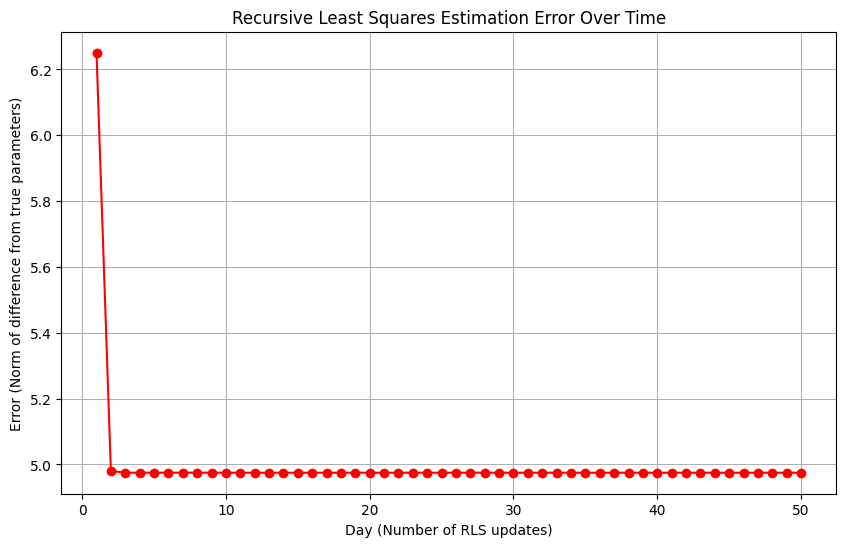

In [15]:
class RecursiveLeastSQ:
    def __init__(self, lambda_=1.0, P0_diag=1e3, name='RecursiveLeastSQ_runner'):
        # lambda_: forgetting factor (0 < lambda_ <= 1)
        # P0_diag: initial diagonal value for P matrix (large value for high initial uncertainty)
        self.name = name
        self.lambda_ = lambda_

        # Number of parameters (T_baseline, W_headwind, W_tailwind, B_Coach A, B_Coach B, B_Coach C)
        self.num_params = 1 + 2 + len(coach_names) # Dynamically calculate num_params

        # Initialize P_k (inverse of S_k) with a large covariance to reflect high initial uncertainty
        self.P_k = P0_diag * np.eye(self.num_params)

        # Initialize x_k (parameter estimate) to zeros or a reasonable prior
        self.x_k = np.zeros((self.num_params, 1))

        self.estimates_history = []
        self.error_history = []
        self.param_names = ['T_baseline', 'W_headwind', 'W_tailwind'] + [f'B_{c}' for c in coach_names]

    def update(self, A_new, b_new, true_params):
        # A_new: single row (1 x num_params) or multiple rows (num_runs_day x num_params) for a given day
        # b_new: single value (1 x 1) or multiple values (num_runs_day x 1) for a given day

        # To process a day's worth of data as a 'batch' within one RLS step (effectively treating it as multiple sequential updates)
        # It's more common to process one observation at a time for true RLS, but for daily data, we can iterate.

        current_P = self.P_k.copy()
        current_x = self.x_k.copy()

        for i in range(A_new.shape[0]):
            A_i = A_new[i:i+1, :]
            b_i = b_new[i:i+1, :]

            # Calculate Kalman Gain-like term K_k+1
            # Denominator: (lambda * I + A_i * P_k * A_i.T)
            denominator = self.lambda_ * np.eye(A_i.shape[0]) + A_i @ current_P @ A_i.T
            K_k1 = current_P @ A_i.T @ np.linalg.inv(denominator)

            # Update parameter estimate x_k+1
            current_x = current_x + K_k1 @ (b_i - A_i @ current_x)

            # Update P_k+1
            current_P = (current_P - K_k1 @ A_i @ current_P) / self.lambda_

        # Store the updated state for the end of the day
        self.P_k = current_P
        self.x_k = current_x

        self.estimates_history.append(self.x_k)
        error = np.linalg.norm(self.x_k - true_params)
        self.error_history.append(error)

    def get_last_estimate(self):
        if self.estimates_history:
            return self.estimates_history[-1]
        return None

    def get_estimate_history(self):
        return np.array(self.estimates_history).squeeze()

    def get_error_history(self):
        return np.array(self.error_history)


# --- Simulation and RLS Application ---

# True parameters for error calculation
true_params_vec = np.array([
    true_baseline_time,
    true_headwind_effect_coeff,
    true_tailwind_effect_coeff
] + list(true_coach_biases.values())).reshape(-1, 1)

rls_estimator = RecursiveLeastSQ(lambda_=0.98, P0_diag=1e3) # Using a forgetting factor of 0.98

# Run RLS day by day
for day in range(1, num_days_to_simulate + 1):
    df_current_day = df_all_data[df_all_data['day'] == day]
    A_current_day, b_current_day, _ = construct_A_b(df_current_day, coach_names)
    rls_estimator.update(A_current_day, b_current_day, true_params_vec)

# Display results
rls_estimates = rls_estimator.get_estimate_history()
rls_errors = rls_estimator.get_error_history()

print(f"\nFinal RLS Estimates after {num_days_to_simulate} days (lambda={rls_estimator.lambda_}):")
for i, param in enumerate(param_names):
    print(f"{param}: {rls_estimates[-1, i]:.4f}")

print("\nTrue Parameters:")
print(f"T_baseline: {true_baseline_time}")
print(f"W_headwind: {true_headwind_effect_coeff}")
print(f"W_tailwind: {true_tailwind_effect_coeff}")
for coach, bias in true_coach_biases.items():
    print(f"B_{coach}: {bias}")

print(f"\nFinal RLS Estimation Error: {rls_errors[-1]:.4f}")

# Plotting the error convergence
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_days_to_simulate + 1), rls_errors, marker='o', linestyle='-', color='red')
plt.title('Recursive Least Squares Estimation Error Over Time')
plt.xlabel('Day (Number of RLS updates)')
plt.ylabel('Error (Norm of difference from true parameters)')
plt.grid(True)
plt.show()

### Comparing Batch LS and RLS Convergence

Let's plot the errors from both Batch LS and RLS on the same graph to visualize their convergence and performance.

We would expect both methods to converge to similar estimates for constant parameters as the amount of data increases, assuming an appropriate forgetting factor (like $\lambda=1$ or close to 1 for RLS). RLS might show a slightly different convergence path due to its sequential updating nature and the impact of the forgetting factor and initial conditions.

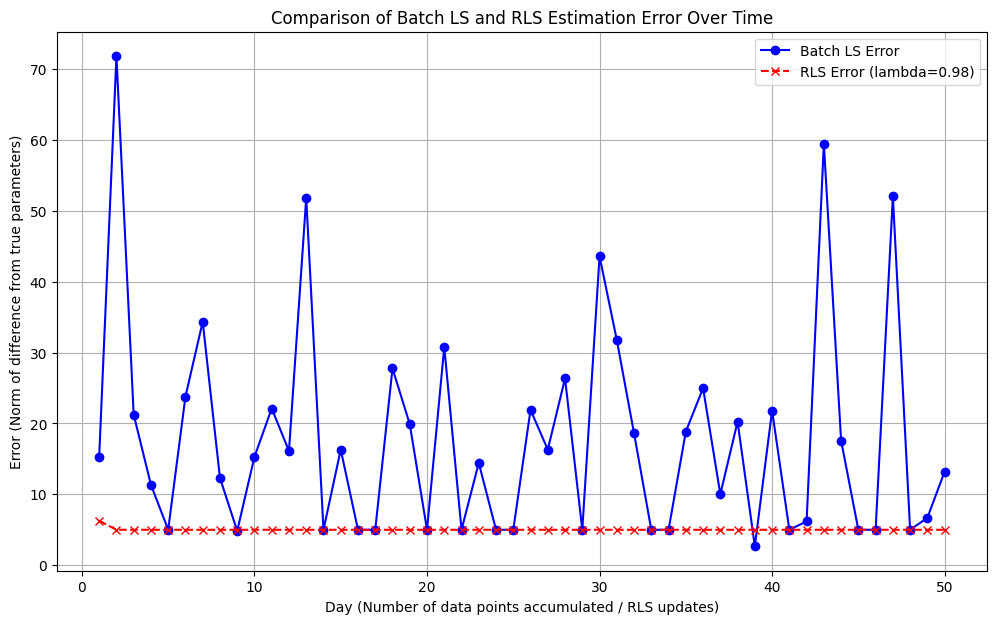

In [16]:
# Plotting Batch LS and RLS error convergence together
plt.figure(figsize=(12, 7))

plt.plot(range(1, num_days_to_simulate + 1), batch_errors, marker='o', linestyle='-', label='Batch LS Error', color='blue')
plt.plot(range(1, num_days_to_simulate + 1), rls_errors, marker='x', linestyle='--', label=f'RLS Error (lambda={rls_estimator.lambda_})', color='red')

plt.title('Comparison of Batch LS and RLS Estimation Error Over Time')
plt.xlabel('Day (Number of data points accumulated / RLS updates)')
plt.ylabel('Error (Norm of difference from true parameters)')
plt.legend()
plt.grid(True)
plt.show()

## Resources

Here are some resources for further learning about Least Squares and Recursive Least Squares:

*   **Books:**
    *   "Optimal Filtering" by Brian D.O. Anderson and John B. Moore
    *   "Kalman Filtering and Neural Networks" edited by Simon Haykin
    *   "Linear Algebra and Its Applications" by Gilbert Strang

*   **Online Courses & Tutorials:**
    *   Coursera: "Linear Algebra for Machine Learning and Data Science"
    *   MIT OpenCourseware: "Linear Algebra (18.06)"
    *   Various online tutorials on RLS and Kalman filters (e.g., from academic institutions or engineering blogs).

*   **Python Libraries:**
    *   `numpy.linalg.lstsq` for standard Least Squares.
    *   Implementations of RLS and Kalman filters can be found in specialized libraries or often implemented from scratch for educational purposes.

*   **Advanced Topics:**
    *   **Proof of optimality for Gaussian residuals:** Explore the statistical properties of LS under assumptions of Gaussian measurement noise, leading to maximum likelihood estimation.
    *   **Extension to nonlinear features:** Discuss how basis functions can be used to model nonlinear relationships while keeping the problem linear in the parameters (e.g., polynomial regression).
    *   **Tricks for estimating some nonlinear parameters:** Introduce iterative methods like Gauss-Newton or Levenberg-Marquardt for truly nonlinear LS problems.
    *   **Estimating coach's measurement bias:** Consider how additional parameters for each coach's bias would expand the design matrix $\mathbf{A}$. For example, if wind speed was directional (e.g., headwind vs. tailwind), you might have two separate parameters impacting the time, one for each direction, adding columns to the $\mathbf{A}$ matrix.

This tutorial primarily focuses on deriving RLS from LS, but these are just a few directions to explore the broad applications and theoretical underpinnings of these powerful estimation techniques.

## References

[1] C. Wang, W. Fu, T. Zhang, M. Zeng, and H. Cheng, “An AOA Optimal Positioning Method Incorporating Station Error and Sensor Deployment,” Aerospace, vol. 9, no. 12, pp. 766–766, Nov. 2022, doi: https://doi.org/10.3390/aerospace9120766  
[22] D. Torrieri, “Statistical Theory of Passive Location Systems,” IEEE Trans. Aerosp. Electron. Syst., vol. AES-20, no. 2, pp. 183–198, Mar. 1984, doi: 10.1109/TAES.1984.310439. [24] https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=1045433